In [175]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
import statsmodels.api as sm

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

df = pd.read_csv("/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")

df.head
df.shape
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [176]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [177]:
df["bmi"].head()
#Use median imputation because bmi is right-skewed (skew > 0.5); median is resistant to 
#outliers/extreme values and better represents the typical patient than mean would

0    36.6
1     NaN
2    32.5
3    34.4
4    24.0
Name: bmi, dtype: float64

In [178]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
# Cell: drop the single 'Other' gender row (n=1, not viable for modeling)
df = df[df['gender'] != 'Other']

# Cell: check duplicates
df.duplicated().sum()

np.int64(0)

In [179]:
#Business task: "Identify which health/lifestyle factors most strongly predict stroke risk, 
#to inform early-warning awareness for at-risk individuals."

desc = df.describe()
desc.loc['skew'] = df.skew(numeric_only=True)
desc

#The high skew on stroke, hypertension, and heart_disease reflects class imbalance, not a data
#quality issue - these are binary risk-factor flags where the minority class (1) is the pattern
#we actually care about. The goal is to find whether people with these conditions are more
#likely to have a stroke, not to "fix" or remove them as outliers.

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,36513.985516,43.229986,0.097475,0.054022,106.140399,28.863300,0.048738
std,21162.008804,22.613575,0.296633,0.226084,45.285004,7.699785,0.215340
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17740.000000,25.000000,0.000000,0.000000,77.240000,23.800000,0.000000
50%,36922.000000,45.000000,0.000000,0.000000,91.880000,28.100000,0.000000
75%,54643.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000
skew,-0.019527,-0.137430,2.715026,3.946786,1.572815,1.087929,4.192807


In [180]:
df['smoking_status'].value_counts()
# Unknown makes up about 30% of our population dataset; therefore, keeping it is a better option

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

In [181]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [182]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [183]:
df['age'].min(), df['age'].max()

(0.08, 82.0)

In [184]:
df = df.drop(columns='id')
#Dropping id to make sure the model doesn't use this for pattern recognition because it doesn't hold any real-world information

In [185]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


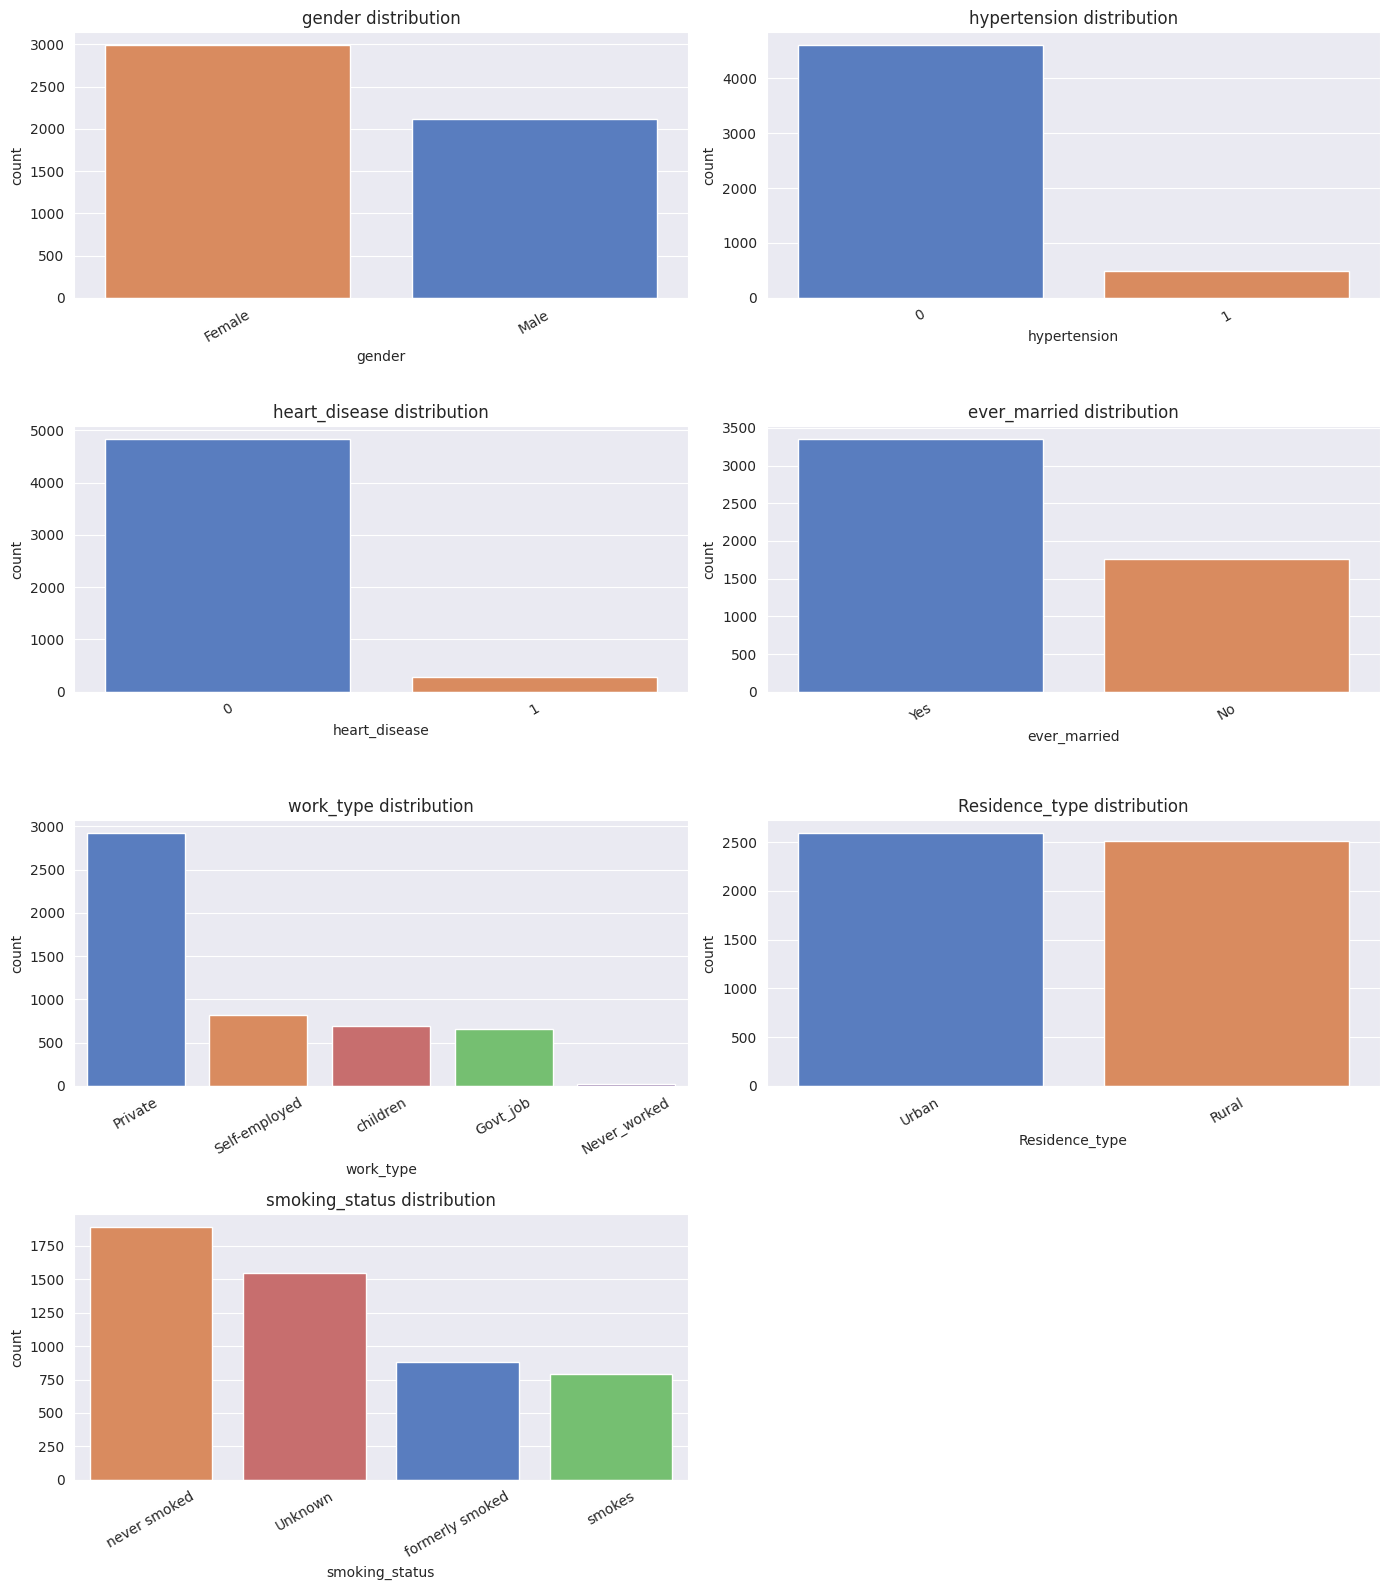

In [186]:
#This code block runs all categorical cols with their distribution, like a count plot for that category: how many people smoked, unknown, etc giving us background of the people that were surveyed.

categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                     'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], order=order, 
                  palette='muted', legend=False)
    axes[i].set_title(f'{col} distribution')
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

#Note - work_type distribution: Govt_job mean Government Job

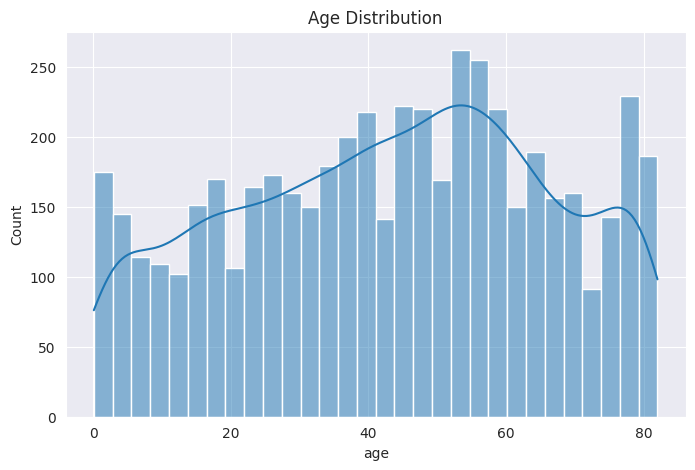

In [187]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

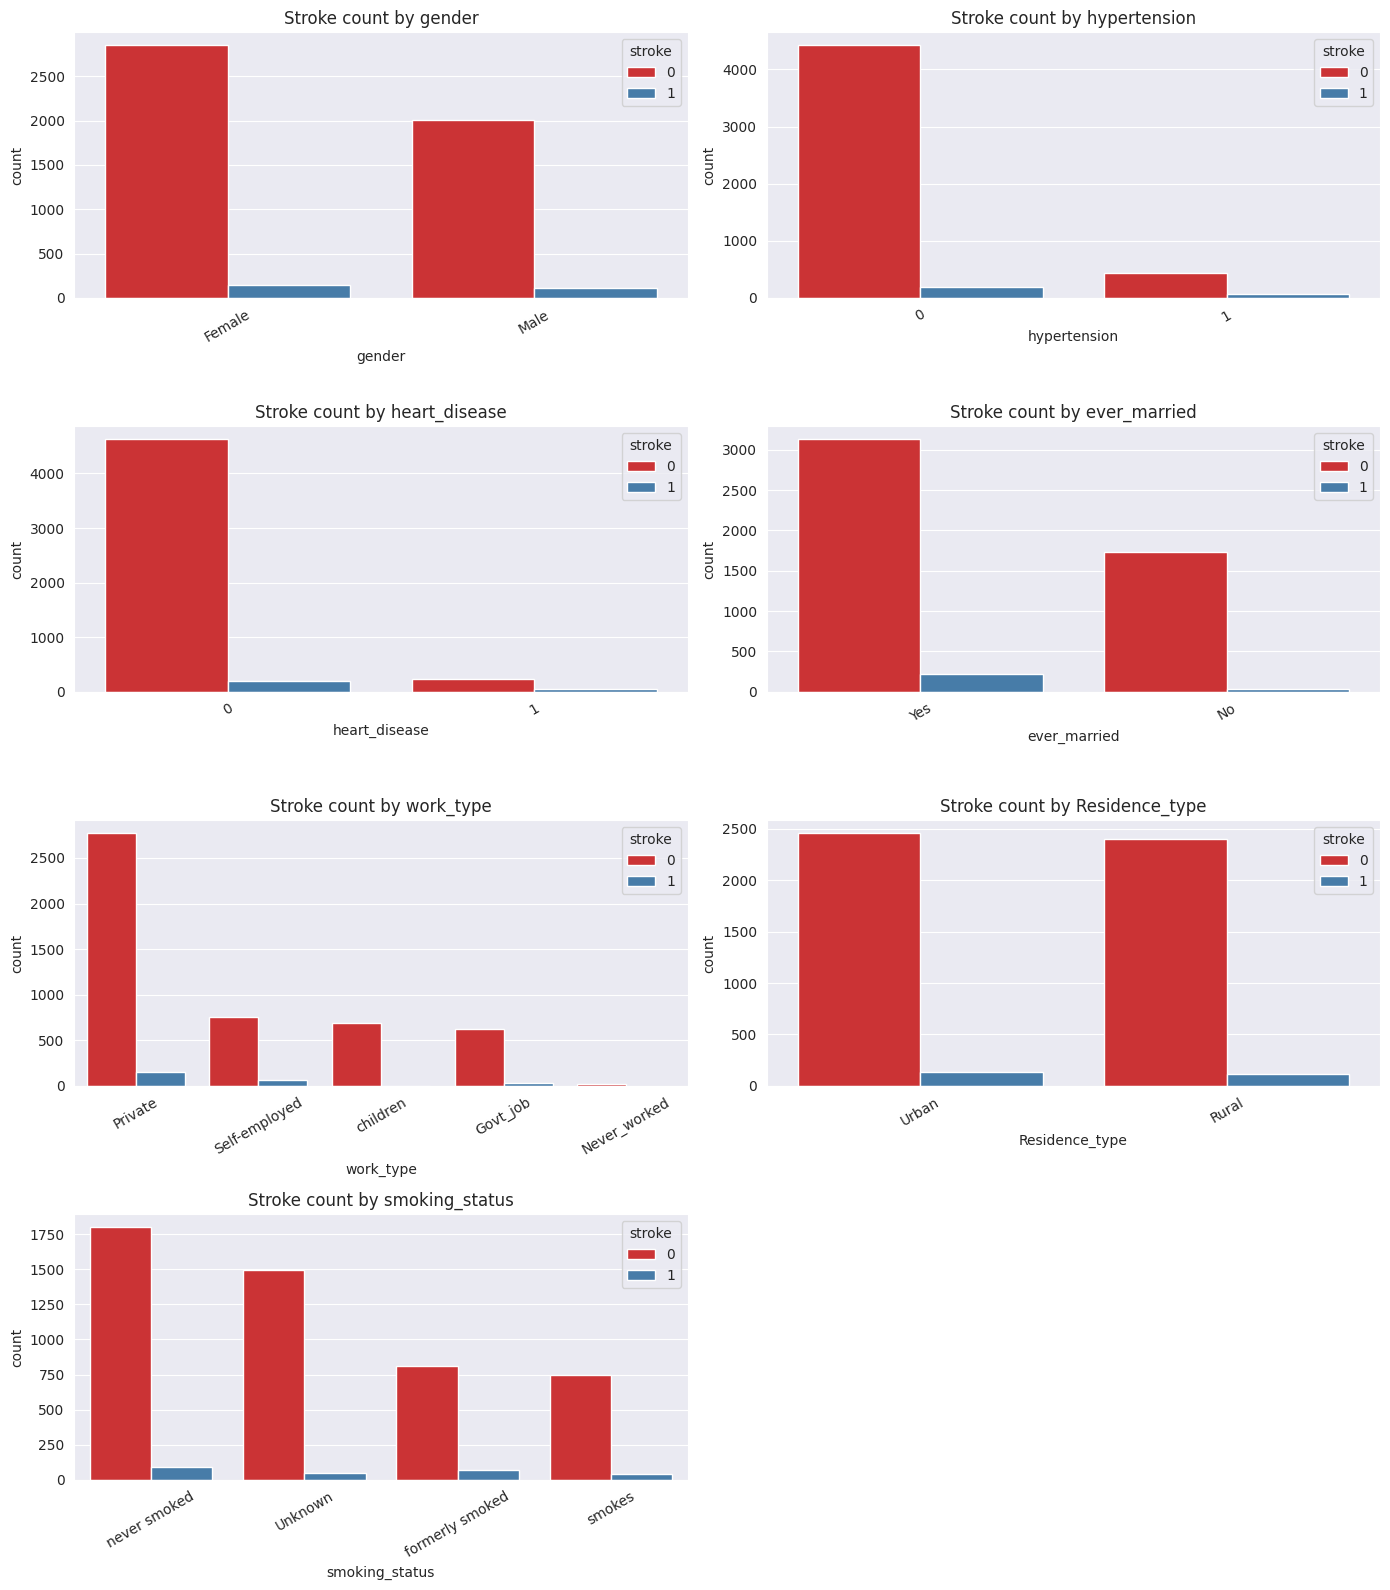

In [188]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                     'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].dropna().unique()  # only categories actually present
    order = sorted(order, key=lambda x: -df[df[col]==x].shape[0])
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], order=order, palette='Set1')
    axes[i].set_title(f'Stroke count by {col}')
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

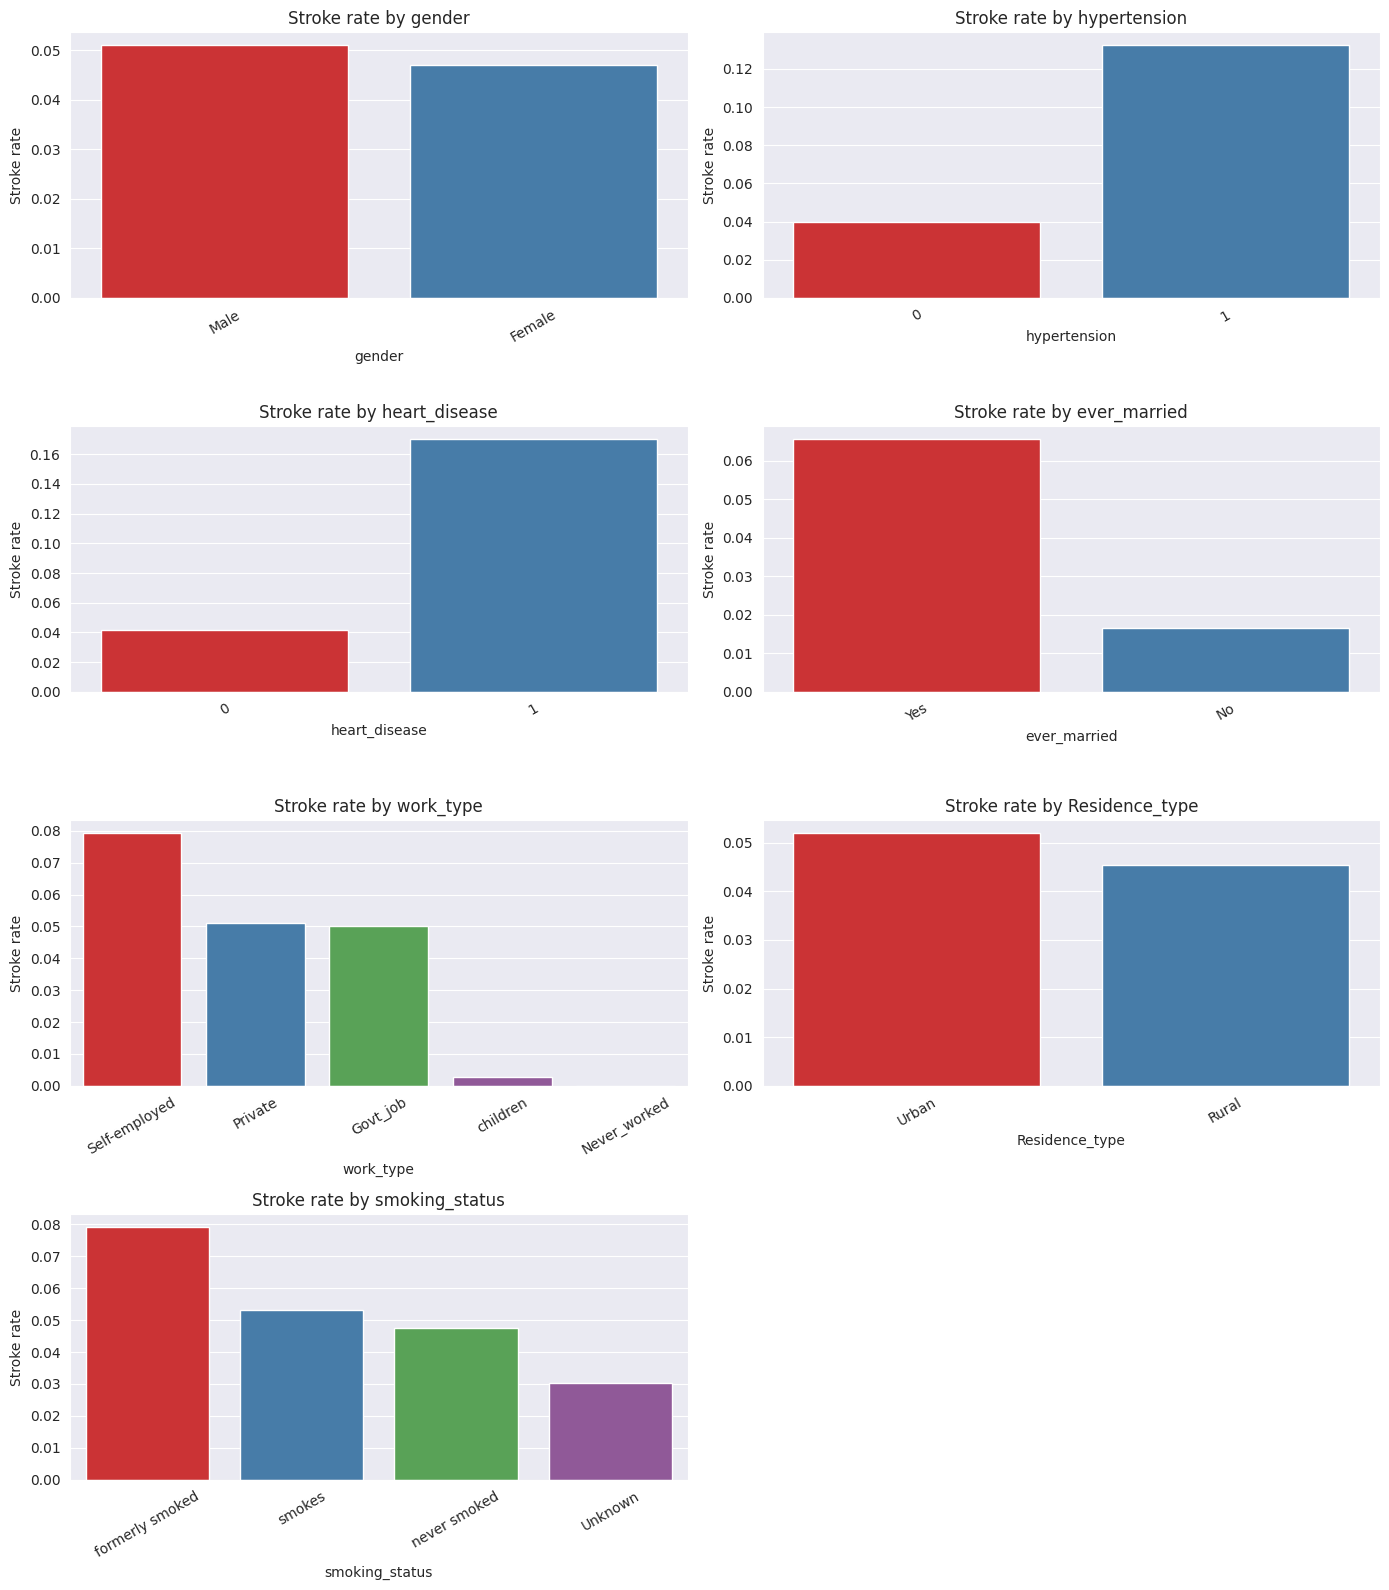

In [189]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                     'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, ax=axes[i], palette='Set1', legend=False)
    axes[i].set_title(f'Stroke rate by {col}')
    axes[i].set_ylabel('Stroke rate')
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

#stroke rate for category X = (number of stroke=1 rows where work_type==X) / (total rows where work_type==X)

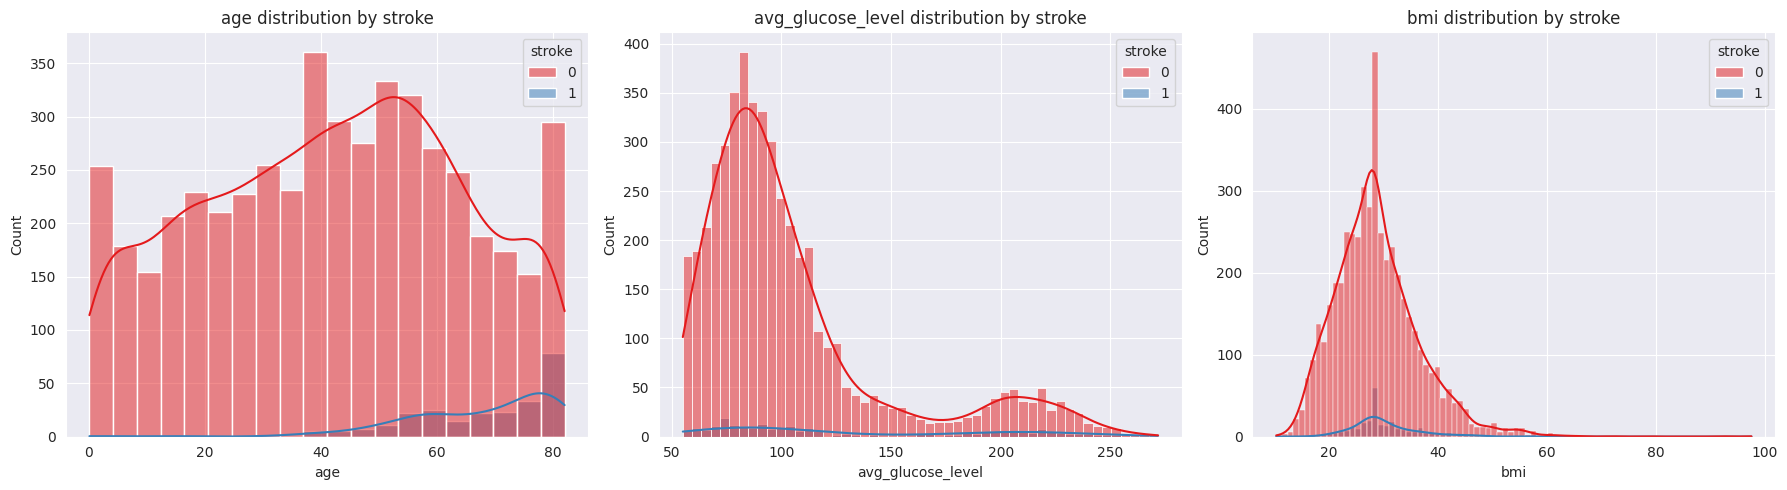

In [190]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='stroke', kde=True, ax=axes[i], multiple='layer', palette='Set1')
    axes[i].set_title(f'{col} distribution by stroke')

plt.tight_layout()
plt.show()

In [191]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df['stroke'] = y_train

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4087, 10)
Test shape: (1022, 10)


In [192]:
from scipy import stats

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
print("=== T-TESTS (numeric vs stroke) ===")
for col in numeric_cols:
    group0 = train_df[train_df['stroke']==0][col]
    group1 = train_df[train_df['stroke']==1][col]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    print(f"{col}: t={t_stat:.3f}, p={p_val:.5f}")

categorical_cols = ['gender','hypertension','heart_disease','ever_married',
                     'work_type','Residence_type','smoking_status']
print("\n=== CHI-SQUARE (categorical vs stroke) ===")
for col in categorical_cols:
    contingency = pd.crosstab(train_df[col], train_df['stroke'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.3f}, p={p:.5f}")

=== T-TESTS (numeric vs stroke) ===
age: t=-28.031, p=0.00000
avg_glucose_level: t=-6.011, p=0.00000
bmi: t=-3.104, p=0.00214

=== CHI-SQUARE (categorical vs stroke) ===
gender: chi2=0.386, p=0.53416
hypertension: chi2=74.011, p=0.00000
heart_disease: chi2=57.794, p=0.00000
ever_married: chi2=45.941, p=0.00000
work_type: chi2=44.117, p=0.00000
Residence_type: chi2=1.185, p=0.27634
smoking_status: chi2=22.838, p=0.00004


In [193]:
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# ensure test has exact same columns as train (in case a category is missing in test split)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(X_train_enc.shape, X_test_enc.shape)

(4087, 15) (1022, 15)


In [194]:
X_train_enc.isnull().sum().sum()
X_train.isnull().sum().sum()
df.isnull().sum().sum()

np.int64(0)

In [195]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']

X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_enc[num_cols])

In [196]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_scaled.astype(float)

vif_df = pd.DataFrame()
vif_df['feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df.sort_values('VIF', ascending=False)

,feature,VIF
6,ever_married_Yes,4.497395
8,work_type_Private,3.397508
0,age,2.801119
10,work_type_children,2.414046
13,smoking_status_never smoked,2.314759
11,Residence_type_Urban,1.902618
9,work_type_Self-employed,1.760658
12,smoking_status_formerly smoked,1.725292
3,gender_Male,1.690597
14,smoking_status_smokes,1.608604


In [197]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 3888, 1: 199}
After SMOTE: {0: 3888, 1: 3888}


In [198]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)   
log_model.fit(X_train_res, y_train_res)
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': log_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df)

                           feature  coefficient
10              work_type_children     2.581081
0                              age     1.945623
8                work_type_Private     1.197621
14           smoking_status_smokes     1.010051
12  smoking_status_formerly smoked     0.952251
4                   hypertension_1     0.935743
6                 ever_married_Yes     0.821125
9          work_type_Self-employed     0.817462
11            Residence_type_Urban     0.760445
13     smoking_status_never smoked     0.651727
5                  heart_disease_1     0.428226
3                      gender_Male     0.209616
1                avg_glucose_level     0.083483
7           work_type_Never_worked    -0.041733
2                              bmi    -0.105407


In [199]:
train_df.groupby('work_type')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
work_type,,,,,,,,
Govt_job,528.0,50.844697,15.457923,14.00,40.00,51.0,62.0,82.0
Never_worked,16.0,16.562500,2.528998,13.00,14.75,17.0,18.0,23.0
Private,2324.0,45.517642,18.434072,8.00,30.00,45.0,59.0,82.0
Self-employed,664.0,60.405120,16.620692,14.00,49.75,63.0,75.0,82.0
children,555.0,6.843315,4.531009,0.08,2.00,6.0,11.0,16.0


In [200]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_preds = rf_model.predict(X_test_scaled)          # ← change this
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]   # ← and this

importance_df = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                           feature  importance
0                              age    0.390647
2                              bmi    0.163961
1                avg_glucose_level    0.158258
6                 ever_married_Yes    0.055442
4                   hypertension_1    0.045254
11            Residence_type_Urban    0.024885
8                work_type_Private    0.023737
5                  heart_disease_1    0.023518
3                      gender_Male    0.021938
9          work_type_Self-employed    0.020879
12  smoking_status_formerly smoked    0.020367
13     smoking_status_never smoked    0.019933
14           smoking_status_smokes    0.017205
10              work_type_children    0.013949
7           work_type_Never_worked    0.000027


In [201]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, roc_auc_score, confusion_matrix, classification_report)

def evaluate(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

evaluate("Logistic Regression", y_test, log_preds, log_probs)
evaluate("Random Forest", y_test, rf_preds, rf_probs)


=== Logistic Regression ===
Accuracy: 0.7661448140900196
Precision: 0.14606741573033707
Recall: 0.78
F1: 0.24605678233438485
ROC-AUC: 0.8325720164609053
Confusion Matrix:
 [[744 228]
 [ 11  39]]

=== Random Forest ===
Accuracy: 0.9001956947162426
Precision: 0.19047619047619047
Recall: 0.32
F1: 0.23880597014925373
ROC-AUC: 0.7747530864197532
Confusion Matrix:
 [[904  68]
 [ 34  16]]
